# **3.  Implement forward propagation and backpropagation using TensorFlow/Keras. Analyze the effect of different learning rates and the number of epochs on model performance.**

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("Training data:", x_train.shape)
print("Testing data:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 439s 3us/step
Training data: (50000, 32, 32, 3)
Testing data: (10000, 32, 32, 3)


In [ ]:
class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

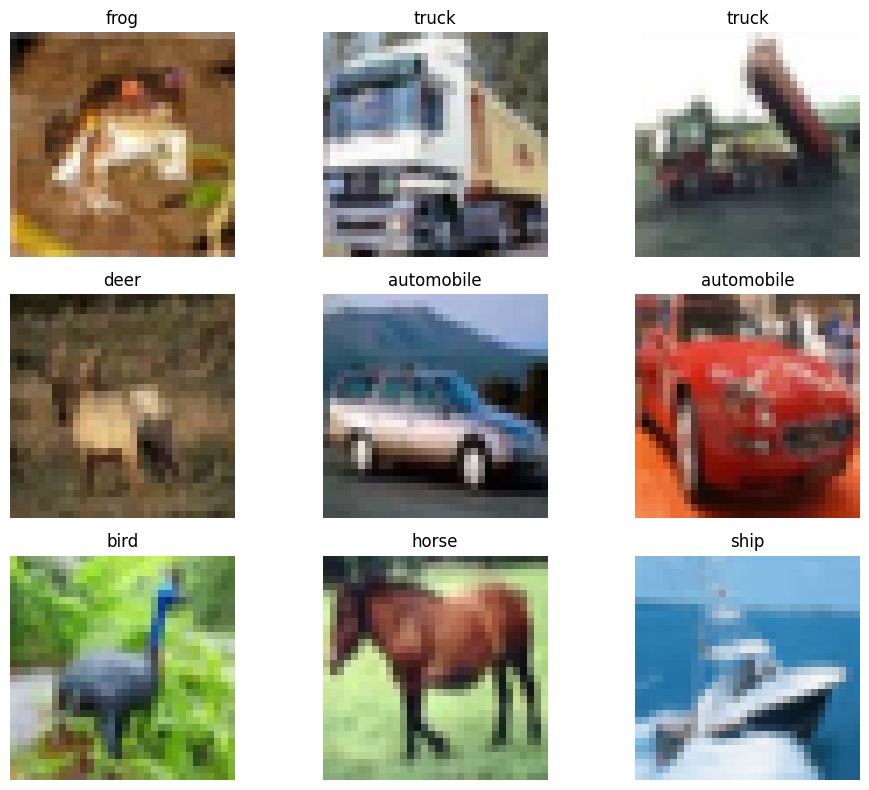

In [ ]:
plt.figure(figsize=(10, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
IMG_SIZE = 96
BATCH_SIZE = 32

train_ds = tf.data.Dataset.from_tensor_slices(
    (x_train, y_train)
)

test_ds = tf.data.Dataset.from_tensor_slices(
    (x_test, y_test)
)

train_ds = train_ds.shuffle(10000).batch(BATCH_SIZE)
test_ds = test_ds.batch(BATCH_SIZE)

In [ ]:
def resize_images(images, labels):
    images = tf.image.resize(
        images,
        (IMG_SIZE, IMG_SIZE)
    )

    return images, labels

train_ds = train_ds.map(resize_images, num_parallel_calls=tf.data.AUTOTUNE)

test_ds = test_ds.map(resize_images,num_parallel_calls=tf.data.AUTOTUNE)

In [ ]:
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

In [ ]:
def create_transfer_model(base_model):

    base_model.trainable = False

    model = tf.keras.Sequential([
        base_model,
        tf.keras.layers.GlobalAveragePooling2D(),

        tf.keras.layers.Dense(128,activation='relu'),

        tf.keras.layers.Dropout(0.5),

        tf.keras.layers.Dense(10,activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
#VGG16
vgg_base = tf.keras.applications.VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

vgg_model = create_transfer_model(vgg_base)

#Training
vgg_history = vgg_model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=1
)

#Evaluates
vgg_loss, vgg_accuracy = vgg_model.evaluate(test_ds)

print("VGG16 Accuracy:", vgg_accuracy)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5629s 4s/step - accuracy: 0.5315 - loss: 1.5236 - val_accuracy: 0.7053 - val_loss: 0.8864
313/313 ━━━━━━━━━━━━━━━━━━━━ 930s 3s/step - accuracy: 0.7053 - loss: 0.8864
VGG16 Accuracy: 0.705299973487854


In [ ]:
#ResNet50
resnet_base = tf.keras.applications.ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

resnet_model = create_transfer_model(resnet_base)

#Train
resnet_history = resnet_model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=1
)

#Evaluate
resnet_loss, resnet_accuracy = resnet_model.evaluate(test_ds)

print("ResNet50 Accuracy:", resnet_accuracy)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1630s 1s/step - accuracy: 0.6638 - loss: 1.0047 - val_accuracy: 0.7722 - val_loss: 0.6650
313/313 ━━━━━━━━━━━━━━━━━━━━ 269s 860ms/step - accuracy: 0.7722 - loss: 0.6650
ResNet50 Accuracy: 0.7721999883651733


In [ ]:
#EfficientNetB0
efficient_base = tf.keras.applications.EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

efficient_model = create_transfer_model(efficient_base)

#Train
efficient_history = efficient_model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=3
)

#Evaluate
efficient_loss, efficient_accuracy = efficient_model.evaluate(test_ds)

print("EfficientNetB0 Accuracy:", efficient_accuracy)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 579s 364ms/step - accuracy: 0.7984 - loss: 0.6165 - val_accuracy: 0.8474 - val_loss: 0.4373
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 668s 393ms/step - accuracy: 0.8376 - loss: 0.4861 - val_accuracy: 0.8553 - val_loss: 0.4191
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 616s 394ms/step - accuracy: 0.8486 - loss: 0.4474 - val_accuracy: 0.8612 - val_loss: 0.4080
313/313 ━━━━━━━━━━━━━━━━━━━━ 92s 295ms/step - accuracy: 0.8612 - loss: 0.4080
EfficientNetB0 Accuracy: 0.8611999750137329


In [ ]:
#AlexNet
alexnet_model = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    tf.keras.layers.Rescaling(1./255),

    tf.keras.layers.Conv2D(96,(11, 11), strides=4, activation='relu'),

    tf.keras.layers.MaxPooling2D((3, 3), strides=2),

    tf.keras.layers.Conv2D(256,(5, 5), padding='same', activation='relu'),

    tf.keras.layers.MaxPooling2D((3, 3),strides=2),

    tf.keras.layers.Conv2D(384,(3, 3), padding='same',activation='relu'),

    tf.keras.layers.Conv2D(384,(3, 3), padding='same', activation='relu'),

    tf.keras.layers.Conv2D(256,(3, 3), padding='same', activation='relu'),

    tf.keras.layers.MaxPooling2D((3, 3), strides=2),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(4096, activation='relu'),

    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(4096, activation='relu'),

    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(10, activation='softmax')])

#Compile
alexnet_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#Train
alexnet_history = alexnet_model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=3
)

#Evaluate
alexnet_loss, alexnet_accuracy = alexnet_model.evaluate(test_ds)

print("AlexNet Accuracy:", alexnet_accuracy)

Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1566s 1s/step - accuracy: 0.0999 - loss: 2.3033 - val_accuracy: 0.1000 - val_loss: 2.3027
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1581s 1000ms/step - accuracy: 0.0990 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3027
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1532s 980ms/step - accuracy: 0.0990 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3026
313/313 ━━━━━━━━━━━━━━━━━━━━ 54s 172ms/step - accuracy: 0.1000 - loss: 2.3026
AlexNet Accuracy: 0.10000000149011612


In [ ]:
#Compare
results = {
    "VGG16": vgg_accuracy,
    "ResNet50": resnet_accuracy,
    "EfficientNetB0": efficient_accuracy,
    "AlexNet": alexnet_accuracy
}

for model_name, accuracy in results.items():
    print(
        model_name,
        ":",
        round(accuracy * 100, 2),
        "%"
    )

VGG16 : 70.53 %
ResNet50 : 77.22 %
EfficientNetB0 : 86.12 %
AlexNet : 10.0 %


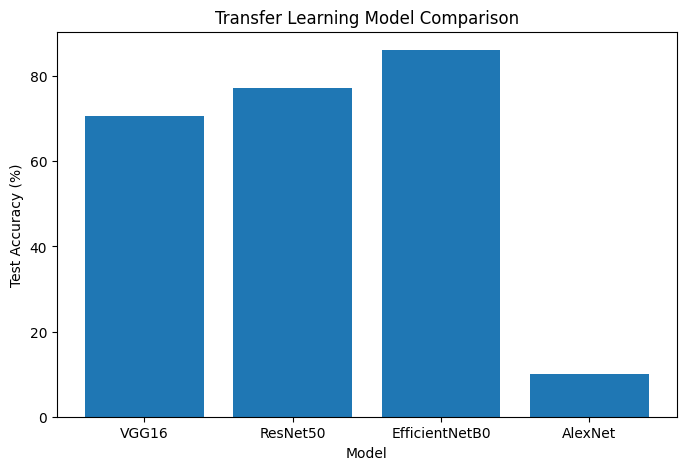

In [ ]:
#Plot Comparison
plt.figure(figsize=(8, 5))

plt.bar(
    results.keys(),
    [accuracy * 100 for accuracy in results.values()]
)

plt.xlabel("Model")
plt.ylabel("Test Accuracy (%)")
plt.title("Transfer Learning Model Comparison")

plt.show()

In [ ]:
#Classification Report
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in test_ds:

    predictions = vgg_model.predict(
        images,
        verbose=0
    )

    predicted_labels = np.argmax(
        predictions,
        axis=1
    )

    y_true.extend(labels.numpy().flatten())
    y_pred.extend(predicted_labels)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

    airplane       0.72      0.75      0.73      1000
  automobile       0.80      0.83      0.82      1000
        bird       0.65      0.56      0.60      1000
         cat       0.55      0.55      0.55      1000
        deer       0.62      0.64      0.63      1000
         dog       0.67      0.63      0.65      1000
        frog       0.69      0.78      0.73      1000
       horse       0.75      0.76      0.75      1000
        ship       0.80      0.73      0.77      1000
       truck       0.80      0.82      0.81      1000

    accuracy                           0.71     10000
   macro avg       0.70      0.71      0.70     10000
weighted avg       0.70      0.71      0.70     10000

